In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from xgboost import XGBRegressor

In [8]:
def load_data(path):
    df=pd.read_csv(path)
    df["TEST_DATE"] = pd.to_datetime(df["TEST_DATE"])
    df = df.sort_values("TEST_DATE").dropna(subset=["OIL"]).reset_index(drop=True)
    df = df[df["OIL"] > 0].reset_index(drop=True)
    return df

In [9]:
def visualize_data(df):
    plt.figure(figsize=(12, 6))
    sns.lineplot(x="TEST_DATE", y="OIL", data=df)
    plt.title("Oil Production Over Time")
    plt.xlabel("Date")
    plt.ylabel("Oil Production")
    plt.show()

In [10]:
def create_dataset(feature_series, target_series, time_steps=30):
    Xs, ys, indices = [], [], []
    for i in range(time_steps, len(feature_series)):
        Xs.append(feature_series[i - time_steps:i])
        ys.append(target_series[i])
        indices.append(i)
    return np.array(Xs), np.array(ys), np.array(indices)

/tmp/ipykernel_248618/2224772952.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["TEST_DATE"] = pd.to_datetime(df["TEST_DATE"])


Cross-Validation Metrics (train, TimeSeriesSplit):


,Model,CV_MAE,CV_RMSE,CV_R2
0,RandomForest,0.17205,0.23921,-0.35962
1,XGBoost,0.17921,0.24748,-0.43561
2,SVR,0.19291,0.25449,-1.40725
3,LinearRegression,0.26932,0.33754,-2.63794



Test Metrics:


,Model,Test_DEC_MAE,Test_DEC_RMSE,Test_DEC_R2,Test_OIL_MAE,Test_OIL_RMSE,Test_OIL_R2
0,RandomForest,0.09674,0.34416,-0.04520,22.70724,41.19353,0.48551
1,XGBoost,0.10077,0.34710,-0.06314,24.21680,45.85527,0.36247
2,SVR,0.12552,0.35105,-0.08745,34.14226,48.49582,0.28693
3,LinearRegression,0.14898,0.35792,-0.13045,42.05977,55.17520,0.07698


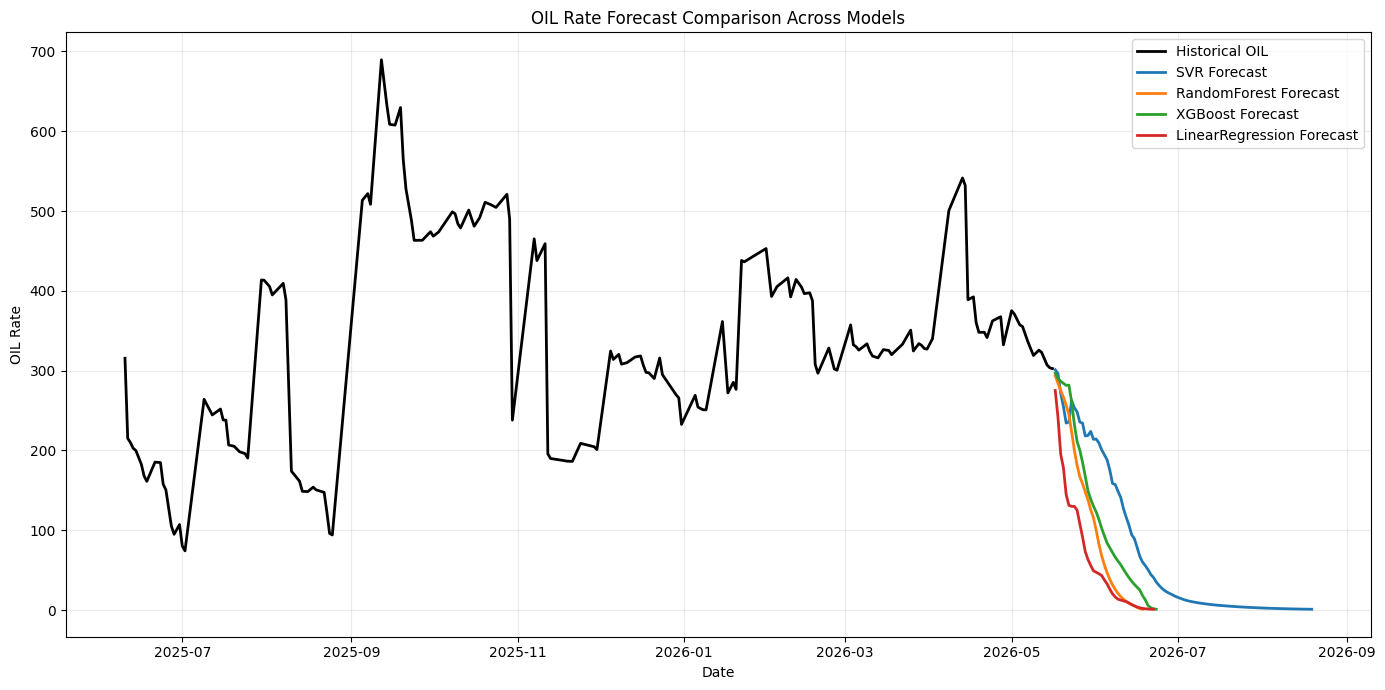

In [11]:
def recursive_oil_forecast(model, history_ln, start_date, date_offset, time_steps, stop_oil=1.0, max_steps=240):
    history = history_ln.copy()
    current_date = start_date
    q_t = float(np.exp(history[-1]))

    forecast_dates = []
    forecast_oil = []

    for _ in range(max_steps):
        if q_t <= stop_oil:
            break

        x_input = np.array(history[-time_steps:]).reshape(1, -1)
        pred_dec_ratio = float(model.predict(x_input)[0])
        q_t = q_t * np.exp(pred_dec_ratio)
        current_date = current_date + date_offset

        if q_t <= stop_oil:
            q_t = stop_oil
            forecast_dates.append(current_date)
            forecast_oil.append(q_t)
            break

        forecast_dates.append(current_date)
        forecast_oil.append(q_t)
        history.append(np.log(q_t))

    return forecast_dates, forecast_oil


def main():
    path = "/home/rian/python_project/myvenv/dca_ml/data/test_data.csv"
    df = load_data(path)

    df["LN_OIL"] = np.log(df["OIL"])
    df["DEC_RATIO"] = np.log(df["OIL"].shift(-1) / df["OIL"])
    df.loc[df["DEC_RATIO"] > 0, "DEC_RATIO"] = np.nan
    df = df.dropna(subset=["DEC_RATIO"]).reset_index(drop=True)

    train_size = int(len(df) * 0.8)
    feature_series = df["LN_OIL"].values
    target_series = df["DEC_RATIO"].values

    time_steps = 30
    X_all, y_all, target_indices = create_dataset(feature_series, target_series, time_steps=time_steps)

    train_mask = target_indices < train_size
    test_mask = ~train_mask

    X_train, y_train = X_all[train_mask], y_all[train_mask]
    X_test, y_test = X_all[test_mask], y_all[test_mask]
    test_target_indices = target_indices[test_mask]

    models = {
        "SVR": make_pipeline(MinMaxScaler(), SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)),
        "RandomForest": RandomForestRegressor(n_estimators=400, random_state=42),
        "XGBoost": XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            objective="reg:squarederror"
        ),
        "LinearRegression": make_pipeline(MinMaxScaler(), LinearRegression()),
    }

    cv = TimeSeriesSplit(n_splits=5)
    scoring = {
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2",
    }

    cv_rows = []
    test_rows = []
    forecast_store = {}

    for name, model in models.items():
        cv_result = cross_validate(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
        )

        cv_rows.append({
            "Model": name,
            "CV_MAE": -np.mean(cv_result["test_MAE"]),
            "CV_RMSE": -np.mean(cv_result["test_RMSE"]),
            "CV_R2": np.mean(cv_result["test_R2"]),
        })

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        dec_mae = mean_absolute_error(y_test, y_pred)
        dec_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        dec_r2 = r2_score(y_test, y_pred)

        valid_mask = (test_target_indices + 1) < len(df)
        current_oil = df["OIL"].values[test_target_indices[valid_mask]]
        next_true_oil = df["OIL"].values[test_target_indices[valid_mask] + 1]
        next_pred_oil = current_oil * np.exp(y_pred[valid_mask])

        oil_mae = mean_absolute_error(next_true_oil, next_pred_oil)
        oil_rmse = np.sqrt(mean_squared_error(next_true_oil, next_pred_oil))
        oil_r2 = r2_score(next_true_oil, next_pred_oil)

        test_rows.append({
            "Model": name,
            "Test_DEC_MAE": dec_mae,
            "Test_DEC_RMSE": dec_rmse,
            "Test_DEC_R2": dec_r2,
            "Test_OIL_MAE": oil_mae,
            "Test_OIL_RMSE": oil_rmse,
            "Test_OIL_R2": oil_r2,
        })

        freq = pd.infer_freq(df["TEST_DATE"]) or "D"
        date_offset = pd.tseries.frequencies.to_offset(freq)
        history_ln = feature_series[-time_steps:].tolist()
        start_date = df["TEST_DATE"].iloc[-1]

        future_dates, future_oil = recursive_oil_forecast(
            model=model,
            history_ln=history_ln,
            start_date=start_date,
            date_offset=date_offset,
            time_steps=time_steps,
            stop_oil=1.0,
            max_steps=240,
        )
        forecast_store[name] = (future_dates, future_oil)

    cv_df = pd.DataFrame(cv_rows).sort_values("CV_RMSE").reset_index(drop=True)
    test_df = pd.DataFrame(test_rows).sort_values("Test_OIL_RMSE").reset_index(drop=True)

    print("Cross-Validation Metrics (train, TimeSeriesSplit):")
    display(cv_df.round(5))
    print("\nTest Metrics:")
    display(test_df.round(5))

    plt.figure(figsize=(14, 7))
    plt.plot(df["TEST_DATE"], df["OIL"], color="black", linewidth=2, label="Historical OIL")

    for name, (f_dates, f_oil) in forecast_store.items():
        if len(f_oil) > 0:
            plt.plot(f_dates, f_oil, linewidth=2, label=f"{name} Forecast")

    plt.title("OIL Rate Forecast Comparison Across Models")
    plt.xlabel("Date")
    plt.ylabel("OIL Rate")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()